In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def generate_gaussian(mu,sigma2,n):
    sigma=np.sqrt(sigma2)
    sample=[]
    while len(sample)<n:
        u1=2*np.random.random()-1
        u2=2*np.random.random()-1
        s=u1*u1+u2*u2
        if 0<s<1:
            k=np.sqrt(-2*np.log(s)/s)
            z1=u1*k
            z2=u2*k
            sample.append(mu+sigma*z1)
            if len(sample)<n:
                sample.append(mu+sigma*z2)
    return sample

n=10000
mu=[np.array([-2.0,0.0]),np.array([2.0,0.0]),np.array([0.0,3.0])]
colors=['salmon','lime','skyblue']
acc_results={}


Case 1: Isotropic covariance with identical covariance for all three classes

train: (24000, 2) test: (6000, 2)
estimated means:
 [[-1.994 -0.004]
 [ 2.001 -0.005]
 [-0.006  2.986]]
estimated common covariance:
 [[0.999 0.   ]
 [0.    0.999]]
estimated priors:
 [0.333 0.333 0.333]
true covariance:
 [[1. 0.]
 [0. 1.]]
accuracy: 94.55%


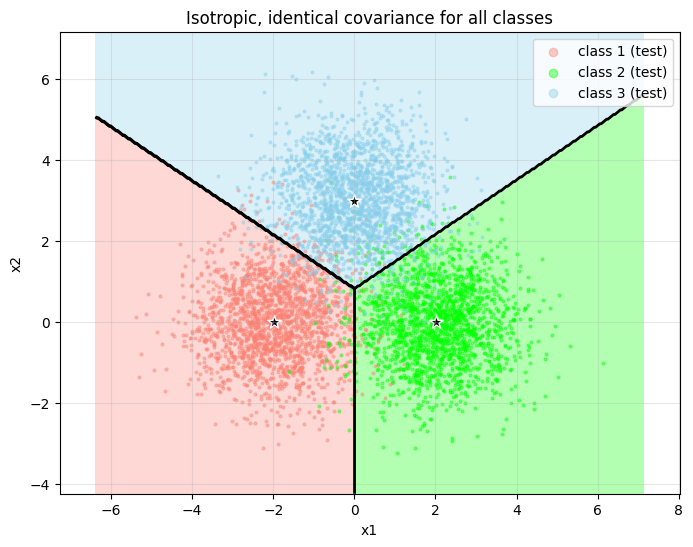

In [6]:
#generate samples

sigma=[np.eye(2),np.eye(2),np.eye(2)]
X_list=[]
y_list=[]
for k in range(3):
    z=np.column_stack((generate_gaussian(0,1,n),generate_gaussian(0,1,n)))
    eigenvalues,eigenvectors=np.linalg.eig(sigma[k])
    sigma_half=eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    X_list.append(z @ sigma_half.T+mu[k])
    y_list.append(np.full(n,k))
X=np.vstack(X_list)
y=np.concatenate(y_list)

#split dataset, train-80, test-20
train_class=[]
test_class=[]
for k in range(3):
    class_rows=np.where(y==k)[0]
    np.random.shuffle(class_rows)
    train_class.append(class_rows[:int(0.8*len(class_rows))])
    test_class.append(class_rows[int(0.8*len(class_rows)):])
train_rows=np.concatenate(train_class)
test_rows=np.concatenate(test_class)
X_train,y_train= X[train_rows],y[train_rows]
X_test,y_test= X[test_rows],y[test_rows]
print("train:",X_train.shape,"test:",X_test.shape)

#estimate parameters from train data
mu_est=[]
prior_est=[]
residuals=[]
for k in range(3):
    Xk=X_train[y_train==k]
    mu_est.append(np.mean(Xk,axis=0))
    prior_est.append(len(Xk)/len(X_train))
    residuals.append(Xk-mu_est[k])

R=np.vstack(residuals) #deviations for all classes from its respective mean
S=R.T @ R/len(R) #common covariance (maximum likelihood)
S=np.trace(S)/2*np.eye(2) #common variance
sigma_est=[S,S,S]
print("estimated means:\n",np.round(mu_est,3))
print("estimated common covariance:\n",np.round(S,3))
print("estimated priors:\n",np.round(prior_est,3))
print("true covariance:\n",np.round(sigma[0],3))

#classify the test data by picking class with max posterior probability and build confusion matrix
scores=np.zeros((len(X_test),3))
for k in range(3):
    diff=X_test-mu_est[k]
    scores[:,k]=-0.5*np.sum(diff @ np.linalg.inv(sigma_est[k])*diff,axis=1)-0.5*np.log(np.linalg.det(sigma_est[k]))+np.log(prior_est[k])
y_pred=np.argmax(scores,axis=1)

confusion_matrix=np.zeros((3,3),dtype=int)
for t,p in zip(y_test,y_pred):
    confusion_matrix[t,p]+=1
accuracy=np.trace(confusion_matrix)/confusion_matrix.sum()
acc_results['Isotropic, identical covariance for all classes']=accuracy*100
print("accuracy: %.2f%%" % (accuracy*100))
pd.DataFrame(confusion_matrix,columns=['predicted 0','predicted 1','predicted 2'],index=['true 0','true 1','true 2'])

#plot the data and decision boundaries
xx, yy = np.meshgrid(np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 400),np.linspace(X_test[:,1].min()-1, X_test[:,1].max()+1, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points),3))
for k in range(3):
    diff = grid_points-mu_est[k]
    grid_scores[:, k]= -0.5 * np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5 * np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region=np.argmax(grid_scores,axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,region,alpha=0.3,levels=[-0.5, 0.5, 1.5, 2.5],colors=colors)
plt.contour(xx,yy,region,levels=[0.5,1.5],colors='black',linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test==k,0],X_test[y_test==k,1],s=4,color=colors[k],alpha=0.4,label='class %d (test)' % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0],mu_est[k][1],s=100,marker='*',color="black",edgecolor="white")
plt.title("Isotropic, identical covariance for all classes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend(markerscale=3)
plt.show()

Case 2: diagonal, identical covariance  for all classes

train: (24000, 2) test: (6000, 2)
estimated means:
 [[-2.041e+00  1.900e-02]
 [ 2.021e+00 -4.000e-03]
 [-1.000e-03  2.982e+00]]
estimated common covariance:
 [[4.025 0.   ]
 [0.    1.014]]
estimated priors:
 [0.333 0.333 0.333]
true covariance:
 [[4. 0.]
 [0. 1.]]
accuracy: 84.70%


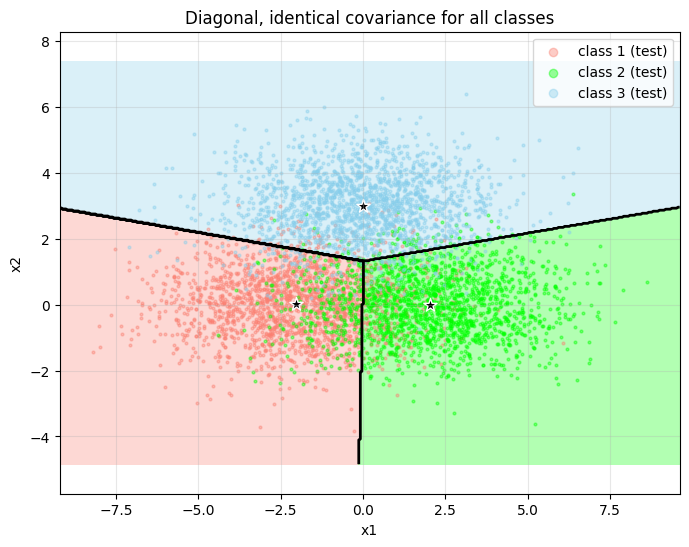

In [7]:
#generate samples

sigma=[np.array([[4.0,0.0],[0.0,1.0]])]*3
X_list=[]
y_list=[]
for k in range(3):
    z=np.column_stack((generate_gaussian(0,1,n),generate_gaussian(0,1,n)))
    eigenvalues,eigenvectors=np.linalg.eig(sigma[k])
    sigma_half=eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    X_list.append(z @ sigma_half.T+mu[k])
    y_list.append(np.full(n,k))
X=np.vstack(X_list)
y=np.concatenate(y_list)

#split dataset, train-80, test-20
train_class=[]
test_class=[]
for k in range(3):
    class_rows=np.where(y==k)[0]
    np.random.shuffle(class_rows)
    train_class.append(class_rows[:int(0.8*len(class_rows))])
    test_class.append(class_rows[int(0.8*len(class_rows)):])
train_rows=np.concatenate(train_class)
test_rows=np.concatenate(test_class)
X_train,y_train= X[train_rows],y[train_rows]
X_test,y_test= X[test_rows],y[test_rows]
print("train:",X_train.shape,"test:",X_test.shape)

#estimate parameters from train data
mu_est=[]
prior_est=[]
residuals=[]
for k in range(3):
    Xk=X_train[y_train==k]
    mu_est.append(np.mean(Xk,axis=0))
    prior_est.append(len(Xk)/len(X_train))
    residuals.append(Xk-mu_est[k])

R=np.vstack(residuals) #deviations for all classes from its respective mean
S=R.T @ R/len(R) #common covariance (maximum likelihood)
S=np.diag(np.diag(S)) #keep only diagonals
sigma_est=[S,S,S]
print("estimated means:\n",np.round(mu_est,3))
print("estimated common covariance:\n",np.round(S,3))
print("estimated priors:\n",np.round(prior_est,3))
print("true covariance:\n",np.round(sigma[0],3))

#classify the test data by picking class with max posterior probability and build confusion matrix
scores=np.zeros((len(X_test),3))
for k in range(3):
    diff=X_test-mu_est[k]
    scores[:,k]=-0.5*np.sum(diff @ np.linalg.inv(sigma_est[k])*diff,axis=1)-0.5*np.log(np.linalg.det(sigma_est[k]))+np.log(prior_est[k])
y_pred=np.argmax(scores,axis=1)

confusion_matrix=np.zeros((3,3),dtype=int)
for t,p in zip(y_test,y_pred):
    confusion_matrix[t,p]+=1
accuracy=np.trace(confusion_matrix)/confusion_matrix.sum()
acc_results['Diagonal, identical covariance for all classes']=accuracy*100
print("accuracy: %.2f%%" % (accuracy*100))
pd.DataFrame(confusion_matrix,columns=['predicted 0','predicted 1','predicted 2'],index=['true 0','true 1','true 2'])

#plot the data and decision boundaries
xx, yy = np.meshgrid(np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 400),np.linspace(X_test[:,1].min()-1, X_test[:,1].max()+1, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points),3))
for k in range(3):
    diff = grid_points-mu_est[k]
    grid_scores[:, k]= -0.5 * np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5 * np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region=np.argmax(grid_scores,axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,region,alpha=0.3,levels=[-0.5, 0.5, 1.5, 2.5],colors=colors)
plt.contour(xx,yy,region,levels=[0.5,1.5],colors='black',linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test==k,0],X_test[y_test==k,1],s=4,color=colors[k],alpha=0.4,label='class %d (test)' % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0],mu_est[k][1],s=100,marker='*',color="black",edgecolor="white")
plt.title("Diagonal, identical covariance for all classes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend(markerscale=3)
plt.show()

Case 3:full, identical covariance for all classes

train: (24000, 2) test: (6000, 2)
estimated means:
 [[-1.998  0.01 ]
 [ 1.978 -0.018]
 [-0.016  2.992]]
estimated common covariance:
 [[2.983 1.502]
 [1.502 1.509]]
estimated priors:
 [0.333 0.333 0.333]
true covariance:
 [[3.  1.5]
 [1.5 1.5]]
accuracy: 89.77%


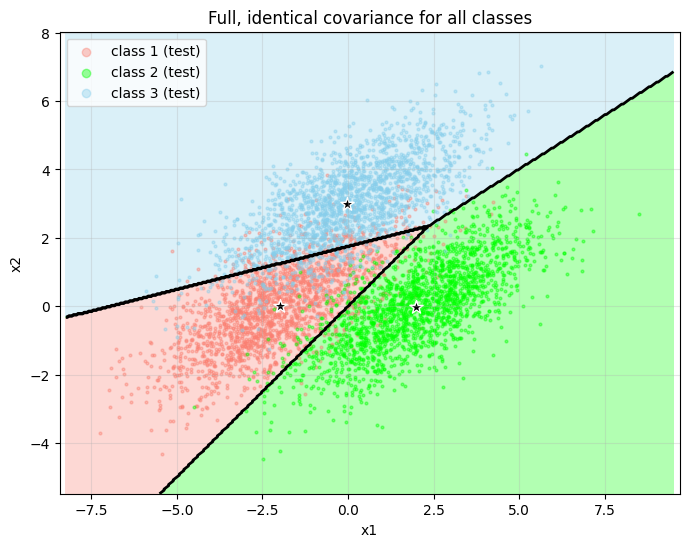

In [8]:
#generate samples

sigma=[np.array([[3.0,1.5],[1.5,1.5]])]*3
X_list=[]
y_list=[]
for k in range(3):
    z=np.column_stack((generate_gaussian(0,1,n),generate_gaussian(0,1,n)))
    eigenvalues,eigenvectors=np.linalg.eig(sigma[k])
    sigma_half=eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    X_list.append(z @ sigma_half.T+mu[k])
    y_list.append(np.full(n,k))
X=np.vstack(X_list)
y=np.concatenate(y_list)

#split dataset, train-80, test-20
train_class=[]
test_class=[]
for k in range(3):
    class_rows=np.where(y==k)[0]
    np.random.shuffle(class_rows)
    train_class.append(class_rows[:int(0.8*len(class_rows))])
    test_class.append(class_rows[int(0.8*len(class_rows)):])
train_rows=np.concatenate(train_class)
test_rows=np.concatenate(test_class)
X_train,y_train= X[train_rows],y[train_rows]
X_test,y_test= X[test_rows],y[test_rows]
print("train:",X_train.shape,"test:",X_test.shape)

#estimate parameters from train data
mu_est=[]
prior_est=[]
residuals=[]
for k in range(3):
    Xk=X_train[y_train==k]
    mu_est.append(np.mean(Xk,axis=0))
    prior_est.append(len(Xk)/len(X_train))
    residuals.append(Xk-mu_est[k])

R=np.vstack(residuals) #deviations for all classes from its respective mean
S=R.T @ R/len(R) #common covariance (maximum likelihood)
sigma_est=[S,S,S]
print("estimated means:\n",np.round(mu_est,3))
print("estimated common covariance:\n",np.round(S,3))
print("estimated priors:\n",np.round(prior_est,3))
print("true covariance:\n",np.round(sigma[0],3))

#classify the test data by picking class with max posterior probability and build confusion matrix
scores=np.zeros((len(X_test),3))
for k in range(3):
    diff=X_test-mu_est[k]
    scores[:,k]=-0.5*np.sum(diff @ np.linalg.inv(sigma_est[k])*diff,axis=1)-0.5*np.log(np.linalg.det(sigma_est[k]))+np.log(prior_est[k])
y_pred=np.argmax(scores,axis=1)

confusion_matrix=np.zeros((3,3),dtype=int)
for t,p in zip(y_test,y_pred):
    confusion_matrix[t,p]+=1
accuracy=np.trace(confusion_matrix)/confusion_matrix.sum()
acc_results['Full, identical covariance for all classes']=accuracy*100
print("accuracy: %.2f%%" % (accuracy*100))
pd.DataFrame(confusion_matrix,columns=['predicted 0','predicted 1','predicted 2'],index=['true 0','true 1','true 2'])

#plot the data and decision boundaries
xx, yy = np.meshgrid(np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 400),np.linspace(X_test[:,1].min()-1, X_test[:,1].max()+1, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points),3))
for k in range(3):
    diff = grid_points-mu_est[k]
    grid_scores[:, k]= -0.5 * np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5 * np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region=np.argmax(grid_scores,axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,region,alpha=0.3,levels=[-0.5, 0.5, 1.5, 2.5],colors=colors)
plt.contour(xx,yy,region,levels=[0.5,1.5],colors='black',linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test==k,0],X_test[y_test==k,1],s=4,color=colors[k],alpha=0.4,label='class %d (test)' % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0],mu_est[k][1],s=100,marker='*',color="black",edgecolor="white")
plt.title("Full, identical covariance for all classes")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend(markerscale=3)
plt.show()

Case 4: Isotropic, different covariances


train: (24000, 2) test: (6000, 2)
estimated means:
 [[-1.996 -0.009]
 [ 1.991  0.017]
 [-0.013  2.999]]
class 1 estimated covariance:
 [[ 1.011 -0.01 ]
 [-0.01   0.97 ]]
class 1 true covariance:
 [[1. 0.]
 [0. 1.]]
class 2 estimated covariance:
 [[2.051e+00 1.000e-03]
 [1.000e-03 1.998e+00]]
class 2 true covariance:
 [[2. 0.]
 [0. 2.]]
class 3 estimated covariance:
 [[0.511 0.004]
 [0.004 0.508]]
class 3 true covariance:
 [[0.5 0. ]
 [0.  0.5]]
accuracy: 93.95%


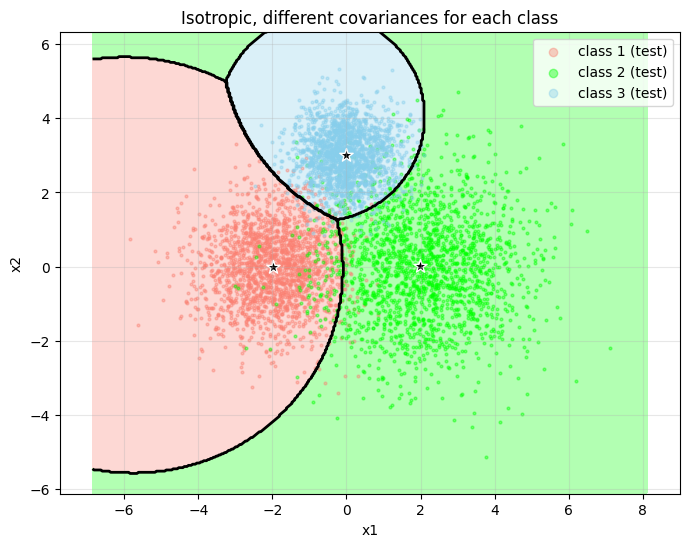

In [9]:
#generate samples

sigma=[1.0*np.eye(2),2.0*np.eye(2),0.5*np.eye(2)]
X_list=[]
y_list=[]
for k in range(3):
    z=np.column_stack((generate_gaussian(0,1,n),generate_gaussian(0,1,n)))
    eigenvalues,eigenvectors=np.linalg.eig(sigma[k])
    sigma_half=eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    X_list.append(z @ sigma_half.T+mu[k])
    y_list.append(np.full(n,k))
X=np.vstack(X_list)
y=np.concatenate(y_list)

#split dataset, train-80, test-20
train_class=[]
test_class=[]
for k in range(3):
    class_rows=np.where(y==k)[0]
    np.random.shuffle(class_rows)
    train_class.append(class_rows[:int(0.8*len(class_rows))])
    test_class.append(class_rows[int(0.8*len(class_rows)):])
train_rows=np.concatenate(train_class)
test_rows=np.concatenate(test_class)
X_train,y_train= X[train_rows],y[train_rows]
X_test,y_test= X[test_rows],y[test_rows]
print("train:",X_train.shape,"test:",X_test.shape)

#estimate parameters from train data
mu_est=[]
prior_est=[]
sigma_est=[]
for k in range(3):
    Xk=X_train[y_train==k]
    mu_k=Xk.mean(axis=0)
    R=Xk-mu_k
    S=R.T @ R/len(R)
    mu_est.append(mu_k)
    prior_est.append(len(Xk)/len(X_train))
    sigma_est.append(S)
print("estimated means:\n",np.round(mu_est,3))
for k in range(3):
    print("class",k+1,"estimated covariance:\n",np.round(sigma_est[k],3))
    print("class",k+1,"true covariance:\n",np.round(sigma[k],3))

#classify the test data by picking class with max posterior probability and build confusion matrix
scores=np.zeros((len(X_test),3))
for k in range(3):
    diff=X_test-mu_est[k]
    scores[:,k]=-0.5*np.sum(diff @ np.linalg.inv(sigma_est[k])*diff,axis=1)-0.5*np.log(np.linalg.det(sigma_est[k]))+np.log(prior_est[k])
y_pred=np.argmax(scores,axis=1)

confusion_matrix=np.zeros((3,3),dtype=int)
for t,p in zip(y_test,y_pred):
    confusion_matrix[t,p]+=1
accuracy=np.trace(confusion_matrix)/confusion_matrix.sum()
acc_results['Isotropic, different covariances for each class']=accuracy*100
print("accuracy: %.2f%%" % (accuracy*100))
pd.DataFrame(confusion_matrix,columns=['predicted 0','predicted 1','predicted 2'],index=['true 0','true 1','true 2'])

#plot the data and decision boundaries
xx, yy = np.meshgrid(np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 400),np.linspace(X_test[:,1].min()-1, X_test[:,1].max()+1, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points),3))
for k in range(3):
    diff = grid_points-mu_est[k]
    grid_scores[:, k]= -0.5 * np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5 * np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region=np.argmax(grid_scores,axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,region,alpha=0.3,levels=[-0.5, 0.5, 1.5, 2.5],colors=colors)
plt.contour(xx,yy,region,levels=[0.5,1.5],colors='black',linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test==k,0],X_test[y_test==k,1],s=4,color=colors[k],alpha=0.4,label='class %d (test)' % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0],mu_est[k][1],s=100,marker='*',color="black",edgecolor="white")
plt.title("Isotropic, different covariances for each class")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend(markerscale=3)
plt.show()

Case 5: Diagonal, different covariances

train: (24000, 2) test: (6000, 2)
estimated means:
 [[-1.989e+00 -2.000e-03]
 [ 2.021e+00 -3.000e-02]
 [-1.400e-02  3.004e+00]]
class 1 estimated covariance:
 [[4.006 0.   ]
 [0.    1.017]]
class 1 true covariance:
 [[4. 0.]
 [0. 1.]]
class 2 estimated covariance:
 [[1.012 0.   ]
 [0.    4.006]]
class 2 true covariance:
 [[1. 0.]
 [0. 4.]]
class 3 estimated covariance:
 [[2.    0.   ]
 [0.    0.497]]
class 3 true covariance:
 [[2.  0. ]
 [0.  0.5]]
accuracy: 88.55%


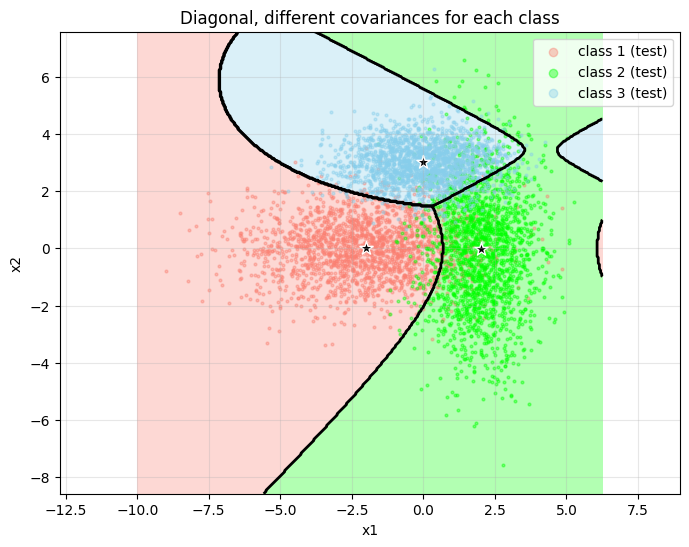

In [10]:
#generate samples

sigma=[np.array([[4.0,0.0],[0.0,1.0]]),np.array([[1.0,0.0],[0.0,4.0]]),np.array([[2.0,0.0],[0.0,0.5]])]
X_list=[]
y_list=[]
for k in range(3):
    z=np.column_stack((generate_gaussian(0,1,n),generate_gaussian(0,1,n)))
    eigenvalues,eigenvectors=np.linalg.eig(sigma[k])
    sigma_half=eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    X_list.append(z @ sigma_half.T+mu[k])
    y_list.append(np.full(n,k))
X=np.vstack(X_list)
y=np.concatenate(y_list)

#split dataset, train-80, test-20
train_class=[]
test_class=[]
for k in range(3):
    class_rows=np.where(y==k)[0]
    np.random.shuffle(class_rows)
    train_class.append(class_rows[:int(0.8*len(class_rows))])
    test_class.append(class_rows[int(0.8*len(class_rows)):])
train_rows=np.concatenate(train_class)
test_rows=np.concatenate(test_class)
X_train,y_train= X[train_rows],y[train_rows]
X_test,y_test= X[test_rows],y[test_rows]
print("train:",X_train.shape,"test:",X_test.shape)

#estimate parameters from train data
mu_est=[]
prior_est=[]
sigma_est=[]
for k in range(3):
    Xk=X_train[y_train==k]
    mu_k=Xk.mean(axis=0)
    R=Xk-mu_k
    S=R.T @ R/len(R)
    S=np.diag(np.diag(S))
    mu_est.append(mu_k)
    prior_est.append(len(Xk)/len(X_train))
    sigma_est.append(S)
print("estimated means:\n",np.round(mu_est,3))
for k in range(3):
    print("class",k+1,"estimated covariance:\n",np.round(sigma_est[k],3))
    print("class",k+1,"true covariance:\n",np.round(sigma[k],3))

#classify the test data by picking class with max posterior probability and build confusion matrix
scores=np.zeros((len(X_test),3))
for k in range(3):
    diff=X_test-mu_est[k]
    scores[:,k]=-0.5*np.sum(diff @ np.linalg.inv(sigma_est[k])*diff,axis=1)-0.5*np.log(np.linalg.det(sigma_est[k]))+np.log(prior_est[k])
y_pred=np.argmax(scores,axis=1)

confusion_matrix=np.zeros((3,3),dtype=int)
for t,p in zip(y_test,y_pred):
    confusion_matrix[t,p]+=1
accuracy=np.trace(confusion_matrix)/confusion_matrix.sum()
acc_results['Diagonal, different covariances for each class']=accuracy*100
print("accuracy: %.2f%%" % (accuracy*100))
pd.DataFrame(confusion_matrix,columns=['predicted 0','predicted 1','predicted 2'],index=['true 0','true 1','true 2'])

#plot the data and decision boundaries
xx, yy = np.meshgrid(np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 400),np.linspace(X_test[:,1].min()-1, X_test[:,1].max()+1, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points),3))
for k in range(3):
    diff = grid_points-mu_est[k]
    grid_scores[:, k]= -0.5 * np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5 * np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region=np.argmax(grid_scores,axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,region,alpha=0.3,levels=[-0.5, 0.5, 1.5, 2.5],colors=colors)
plt.contour(xx,yy,region,levels=[0.5,1.5],colors='black',linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test==k,0],X_test[y_test==k,1],s=4,color=colors[k],alpha=0.4,label='class %d (test)' % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0],mu_est[k][1],s=100,marker='*',color="black",edgecolor="white")
plt.title("Diagonal, different covariances for each class")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend(markerscale=3)
plt.show()

Case 6: Full, different covariances

train: (24000, 2) test: (6000, 2)
estimated means:
 [[-2.002e+00 -1.000e-03]
 [ 1.989e+00  1.400e-02]
 [-1.300e-02  3.016e+00]]
class 1 estimated covariance:
 [[3.019 1.475]
 [1.475 1.501]]
class 1 true covariance:
 [[3.  1.5]
 [1.5 1.5]]
class 2 estimated covariance:
 [[ 2.969 -1.509]
 [-1.509  1.522]]
class 2 true covariance:
 [[ 3.  -1.5]
 [-1.5  1.5]]
class 3 estimated covariance:
 [[1.498 0.496]
 [0.496 0.995]]
class 3 true covariance:
 [[1.5 0.5]
 [0.5 1. ]]
accuracy: 86.70%


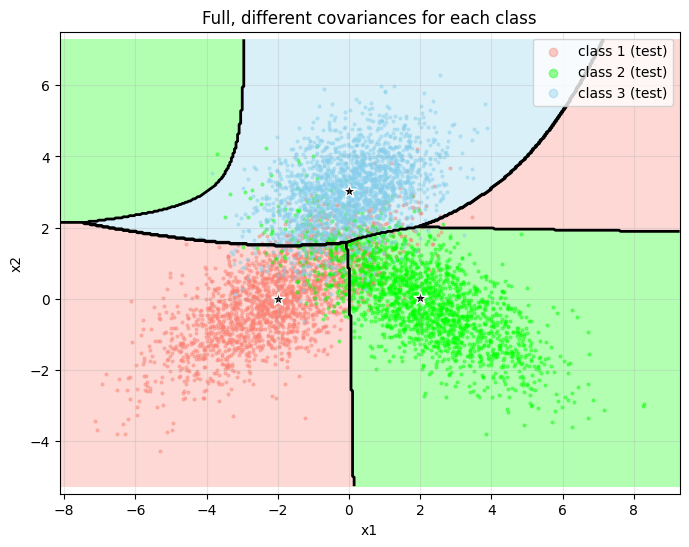

In [11]:
#generate samples

sigma=[np.array([[3.0,1.5],[1.5,1.5]]),np.array([[3.0,-1.5],[-1.5,1.5]]),np.array([[1.5,0.5],[0.5,1.0]])]
X_list=[]
y_list=[]
for k in range(3):
    z=np.column_stack((generate_gaussian(0,1,n),generate_gaussian(0,1,n)))
    eigenvalues,eigenvectors=np.linalg.eig(sigma[k])
    sigma_half=eigenvectors @ np.diag(np.sqrt(eigenvalues)) @ eigenvectors.T
    X_list.append(z @ sigma_half.T+mu[k])
    y_list.append(np.full(n,k))
X=np.vstack(X_list)
y=np.concatenate(y_list)

#split dataset, train-80, test-20
train_class=[]
test_class=[]
for k in range(3):
    class_rows=np.where(y==k)[0]
    np.random.shuffle(class_rows)
    train_class.append(class_rows[:int(0.8*len(class_rows))])
    test_class.append(class_rows[int(0.8*len(class_rows)):])
train_rows=np.concatenate(train_class)
test_rows=np.concatenate(test_class)
X_train,y_train= X[train_rows],y[train_rows]
X_test,y_test= X[test_rows],y[test_rows]
print("train:",X_train.shape,"test:",X_test.shape)

#estimate parameters from train data
mu_est=[]
prior_est=[]
sigma_est=[]
for k in range(3):
    Xk=X_train[y_train==k]
    mu_k=Xk.mean(axis=0)
    R=Xk-mu_k
    S=R.T @ R/len(R)
    mu_est.append(mu_k)
    prior_est.append(len(Xk)/len(X_train))
    sigma_est.append(S)
print("estimated means:\n",np.round(mu_est,3))
for k in range(3):
    print("class",k+1,"estimated covariance:\n",np.round(sigma_est[k],3))
    print("class",k+1,"true covariance:\n",np.round(sigma[k],3))

#classify the test data by picking class with max posterior probability and build confusion matrix
scores=np.zeros((len(X_test),3))
for k in range(3):
    diff=X_test-mu_est[k]
    scores[:,k]=-0.5*np.sum(diff @ np.linalg.inv(sigma_est[k])*diff,axis=1)-0.5*np.log(np.linalg.det(sigma_est[k]))+np.log(prior_est[k])
y_pred=np.argmax(scores,axis=1)

confusion_matrix=np.zeros((3,3),dtype=int)
for t,p in zip(y_test,y_pred):
    confusion_matrix[t,p]+=1
accuracy=np.trace(confusion_matrix)/confusion_matrix.sum()
acc_results['Full, different covariances for each class']=accuracy*100
print("accuracy: %.2f%%" % (accuracy*100))
pd.DataFrame(confusion_matrix,columns=['predicted 0','predicted 1','predicted 2'],index=['true 0','true 1','true 2'])

#plot the data and decision boundaries
xx, yy = np.meshgrid(np.linspace(X_test[:,0].min()-1, X_test[:,0].max()+1, 400),np.linspace(X_test[:,1].min()-1, X_test[:,1].max()+1, 400))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_scores = np.zeros((len(grid_points),3))
for k in range(3):
    diff = grid_points-mu_est[k]
    grid_scores[:, k]= -0.5 * np.sum(diff @ np.linalg.inv(sigma_est[k]) * diff, axis=1) - 0.5 * np.log(np.linalg.det(sigma_est[k])) + np.log(prior_est[k])
region=np.argmax(grid_scores,axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx,yy,region,alpha=0.3,levels=[-0.5, 0.5, 1.5, 2.5],colors=colors)
plt.contour(xx,yy,region,levels=[0.5,1.5],colors='black',linewidths=2)
for k in range(3):
    plt.scatter(X_test[y_test==k,0],X_test[y_test==k,1],s=4,color=colors[k],alpha=0.4,label='class %d (test)' % (k+1))
for k in range(3):
    plt.scatter(mu_est[k][0],mu_est[k][1],s=100,marker='*',color="black",edgecolor="white")
plt.title("Full, different covariances for each class")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend(markerscale=3)
plt.show()